In [1]:
# Import necessary libraries
import cv2
import os
from keras.models import Model, Sequential
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import numpy as np
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from keras.optimizers import Adam

In [2]:
# Define paths for your dataset of eye and mouth images
open_eye_dir = 'C:/ALL/Project Final year/eye and mouth ML HAAR/dataset_new/train/open_eyes'
closed_eye_dir = 'C:/ALL/Project Final year/eye and mouth ML HAAR/dataset_new/train/closed_eyes'
mouth_open_dir = 'C:/ALL/Project Final year/eye and mouth ML HAAR/dataset_new/train/yawn'
mouth_closed_dir = 'C:/ALL/Project Final year/eye and mouth ML HAAR/dataset_new/train/no_yawn'

In [3]:
# Prepare lists to store images and labels
eye_images = []
eye_labels = []
mouth_images = []
mouth_labels = []

In [4]:
# Load eye images and assign labels
for file in os.listdir(open_eye_dir):
    img = cv2.imread(os.path.join(open_eye_dir, file), cv2.IMREAD_GRAYSCALE)
    if img is not None:
        img = cv2.resize(img, (24, 24))
        eye_images.append(img)
        eye_labels.append(1)  # Label for open eyes

for file in os.listdir(closed_eye_dir):
    img = cv2.imread(os.path.join(closed_eye_dir, file), cv2.IMREAD_GRAYSCALE)
    if img is not None:
        img = cv2.resize(img, (24, 24))
        eye_images.append(img)
        eye_labels.append(0)  # Label for closed eyes

In [5]:
# Load mouth images and assign labels
for file in os.listdir(mouth_open_dir):
    img = cv2.imread(os.path.join(mouth_open_dir, file), cv2.IMREAD_GRAYSCALE)
    if img is not None:
        img = cv2.resize(img, (24, 24))
        mouth_images.append(img)
        mouth_labels.append(1)  # Label for yawning

for file in os.listdir(mouth_closed_dir):
    img = cv2.imread(os.path.join(mouth_closed_dir, file), cv2.IMREAD_GRAYSCALE)
    if img is not None:
        img = cv2.resize(img, (24, 24))
        mouth_images.append(img)
        mouth_labels.append(0)  # Label for no yawning

In [6]:
# Convert to numpy arrays
eye_images = np.array(eye_images).reshape(-1, 24, 24, 1)
mouth_images = np.array(mouth_images).reshape(-1, 24, 24, 1)
eye_labels = np.array(eye_labels)
mouth_labels = np.array(mouth_labels)


In [7]:
# Normalize the images
eye_images = eye_images / 255.0
mouth_images = mouth_images / 255.0

In [8]:
# One-hot encode the labels (binary classification)
eye_labels = to_categorical(eye_labels, num_classes=2)
mouth_labels = to_categorical(mouth_labels, num_classes=2)


In [9]:
# Split data into training and test sets
X_train_eye, X_test_eye, y_train_eye, y_test_eye = train_test_split(eye_images, eye_labels, test_size=0.2, random_state=42)
X_train_mouth, X_test_mouth, y_train_mouth, y_test_mouth = train_test_split(mouth_images, mouth_labels, test_size=0.2, random_state=42)

In [21]:
# Shared convolutional layers for both tasks
x = Conv2D(64, (3, 3), activation='relu')(input_layer)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(64, (3, 3), activation='relu')(x)
x = MaxPooling2D((2, 2))(x)
x = Flatten()(x)


In [22]:
# Eye output (open/closed)
eye_output = Dense(2, activation='softmax', name='eye_output')(x)

# Mouth output (yawn/not yawn)
mouth_output = Dense(2, activation='softmax', name='mouth_output')(x)

# Define the model with two outputs
model = Model(inputs=input_layer, outputs=[eye_output, mouth_output])

In [14]:
# Create a new Sequential model
model = Sequential()

# Add convolutional layers
model.add(Conv2D(64, (3, 3), activation='relu', input_shape=(24, 24, 1)))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

In [18]:
# Flatten the output
model.add(Flatten())

# Fully connected layer
model.add(Dense(128, activation='relu'))

# Output layer with 4 nodes (2 for Eye, 2 for Mouth)
model.add(Dense(4, activation='softmax'))

# Compile the model
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])


In [19]:
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from keras.models import Model

# Define input layer
input_layer = Input(shape=(24, 24, 1))

# Shared convolutional layers
x = Conv2D(64, (3, 3), activation='relu')(input_layer)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(64, (3, 3), activation='relu')(x)
x = MaxPooling2D((2, 2))(x)
x = Flatten()(x)  # Flattening the output to pass to fully connected layers

# Create two outputs from the shared convolutional layers
eye_output = Dense(2, activation='softmax', name='eye_output')(x)
mouth_output = Dense(2, activation='softmax', name='mouth_output')(x)

# Define the model with two outputs
model = Model(inputs=input_layer, outputs=[eye_output, mouth_output])

# Compile the model with two losses (one for each output)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Summary of the model
model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 24, 24, 1)]          0         []                            
                                                                                                  
 conv2d_2 (Conv2D)           (None, 22, 22, 64)           640       ['input_1[0][0]']             
                                                                                                  
 max_pooling2d_2 (MaxPoolin  (None, 11, 11, 64)           0         ['conv2d_2[0][0]']            
 g2D)                                                                                             
                                                                                                  
 conv2d_3 (Conv2D)           (None, 9, 9, 64)             36928     ['max_pooling2d_2[0][0]'] 

In [23]:
# Compile the model with two losses
model.compile(optimizer=Adam(), 
              loss={'eye_output': 'categorical_crossentropy', 'mouth_output': 'categorical_crossentropy'}, 
              metrics=['accuracy'])

In [24]:
# Train the model
epochs = 30
history = model.fit(
    {'input_1': X_train_eye, 'input_2': X_train_mouth},
    {'eye_output': y_train_eye, 'mouth_output': y_train_mouth},
    epochs=epochs,
    validation_data=({'input_1': X_test_eye, 'input_2': X_test_mouth},
                     {'eye_output': y_test_eye, 'mouth_output': y_test_mouth}),
    batch_size=32
)

Epoch 1/30


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\keras\src\engine\functional.py:639: UserWarning: Input dict contained keys ['input_2'] which did not match any model input. They will be ignored by the model.
  inputs = self._flatten_to_reference_inputs(inputs)


34/34 [==============================] - 3s 29ms/step - loss: 1.1460 - eye_output_loss: 0.5665 - mouth_output_loss: 0.5794 - eye_output_accuracy: 0.7702 - mouth_output_accuracy: 0.7377 - val_loss: 0.8759 - val_eye_output_loss: 0.4277 - val_mouth_output_loss: 0.4482 - val_eye_output_accuracy: 0.8141 - val_mouth_output_accuracy: 0.8067
Epoch 2/30
34/34 [==============================] - 1s 21ms/step - loss: 0.6905 - eye_output_loss: 0.3246 - mouth_output_loss: 0.3659 - eye_output_accuracy: 0.8837 - mouth_output_accuracy: 0.8633 - val_loss: 0.5977 - val_eye_output_loss: 0.2881 - val_mouth_output_loss: 0.3096 - val_eye_output_accuracy: 0.8996 - val_mouth_output_accuracy: 0.9071
Epoch 3/30
34/34 [==============================] - 1s 21ms/step - loss: 0.5457 - eye_output_loss: 0.2439 - mouth_output_loss: 0.3018 - eye_output_accuracy: 0.9088 - mouth_output_accuracy: 0.8977 - val_loss: 0.5175 - val_eye_output_loss: 0.2338 - val_mouth_output_loss: 0.2837 - val_eye_output_accuracy: 0.9182 - val_

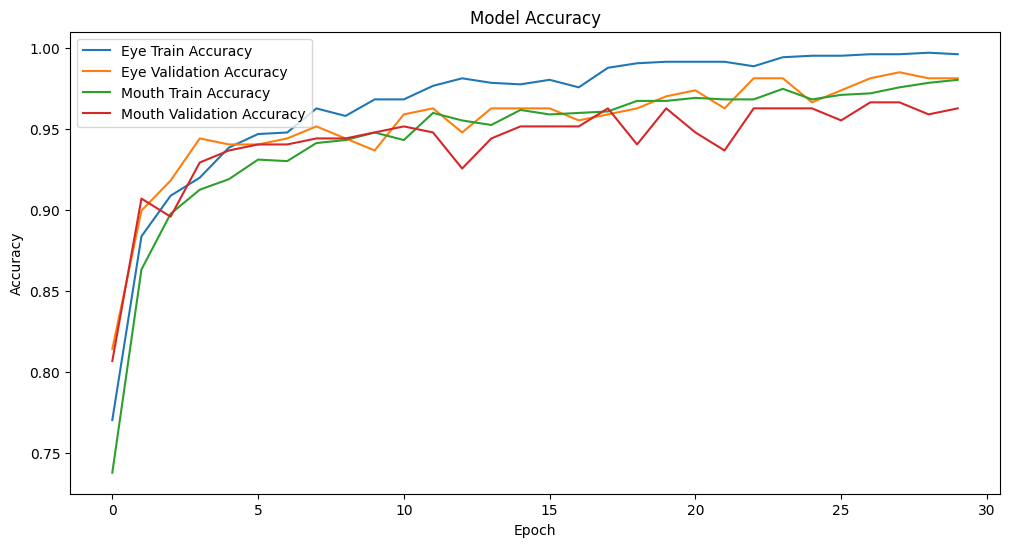

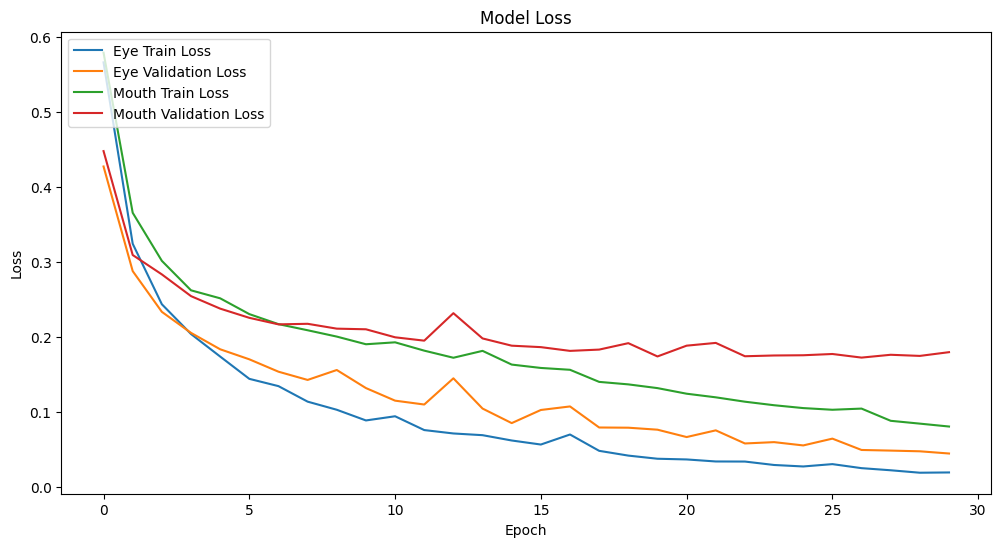

In [26]:
# Plot accuracy and loss graph for both eye and mouth classification
plt.figure(figsize=(12, 6))
plt.plot(history.history['eye_output_accuracy'], label='Eye Train Accuracy')
plt.plot(history.history['val_eye_output_accuracy'], label='Eye Validation Accuracy')
plt.plot(history.history['mouth_output_accuracy'], label='Mouth Train Accuracy')
plt.plot(history.history['val_mouth_output_accuracy'], label='Mouth Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

# Optionally, plot the loss for both outputs
plt.figure(figsize=(12, 6))
plt.plot(history.history['eye_output_loss'], label='Eye Train Loss')
plt.plot(history.history['val_eye_output_loss'], label='Eye Validation Loss')
plt.plot(history.history['mouth_output_loss'], label='Mouth Train Loss')
plt.plot(history.history['val_mouth_output_loss'], label='Mouth Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

In [27]:
# Predict on test set for both outputs
y_pred_eye = model.predict(X_test_eye)
y_pred_eye_class = np.argmax(y_pred_eye[0], axis=1)
y_test_eye_class = np.argmax(y_test_eye, axis=1)

y_pred_mouth = model.predict(X_test_mouth)
y_pred_mouth_class = np.argmax(y_pred_mouth[1], axis=1)
y_test_mouth_class = np.argmax(y_test_mouth, axis=1)

9/9 [==============================] - 0s 9ms/step


In [28]:
# Calculate the confusion matrix for eyes and mouth
conf_mat_eye = confusion_matrix(y_test_eye_class, y_pred_eye_class)
conf_mat_mouth = confusion_matrix(y_test_mouth_class, y_pred_mouth_class)
print("Confusion Matrix for Eyes:")
print(conf_mat_eye)
print("Confusion Matrix for Mouth:")
print(conf_mat_mouth)

Confusion Matrix for Eyes:
[[132   0]
 [  5 132]]
Confusion Matrix for Mouth:
[[80 54]
 [58 77]]


In [29]:
# Save the model
model.save('models/eye_and_mouth_model_cnn.h5')

C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
